# CKD — Exploratory Data Analysis
Dataset: UCI Chronic Kidney Disease, 24 attributes + class.
This dataset is messier than the others: many columns are
stored as text (with stray spaces / `?` for missing), so
expect more cleanup here than in diabetes or heart disease.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the dataset
Columns: age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc,
sod, pot, hemo, pcv, wc, rc, htn, dm, cad, appet, pe, ane, class

In [2]:
df = pd.read_csv("../../data/raw/ckd.csv")
df.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## 2. Basic info
Watch for `pcv`, `wc`, `rc` showing up as `object` dtype —
that means they contain non-numeric junk (spaces, `?`) that
needs cleaning before they can be used as numbers.

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (400, 26)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null 

## 3. Check for missing / invalid values
This dataset uses `?` for missing values in many columns,
and some text columns have stray leading/trailing spaces
(e.g. ' yes' instead of 'yes').

In [4]:
for col in df.columns:
    n_question_mark = (df[col].astype(str).str.strip() == "?").sum()
    if n_question_mark:
        print(f"{col}: {n_question_mark} '?' values")


pcv: 1 '?' values
wc: 1 '?' values
rc: 1 '?' values


## 4. Class balance
`class` — 'ckd' or 'notckd' (values may have trailing spaces).

classification
ckd       250
notckd    150
Name: count, dtype: int64


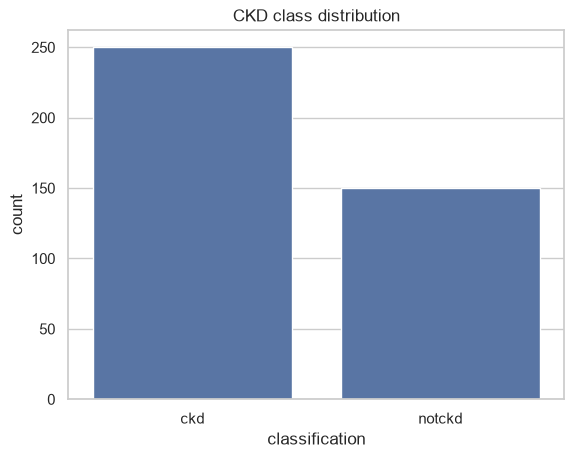

In [6]:
df["classification"] = df["classification"].astype(str).str.strip()
print(df["classification"].value_counts())

sns.countplot(x="classification", data=df)
plt.title("CKD class distribution")
plt.show()


## 5. Numeric feature distributions
(Only truly numeric columns — categorical ones are explored
separately below.)

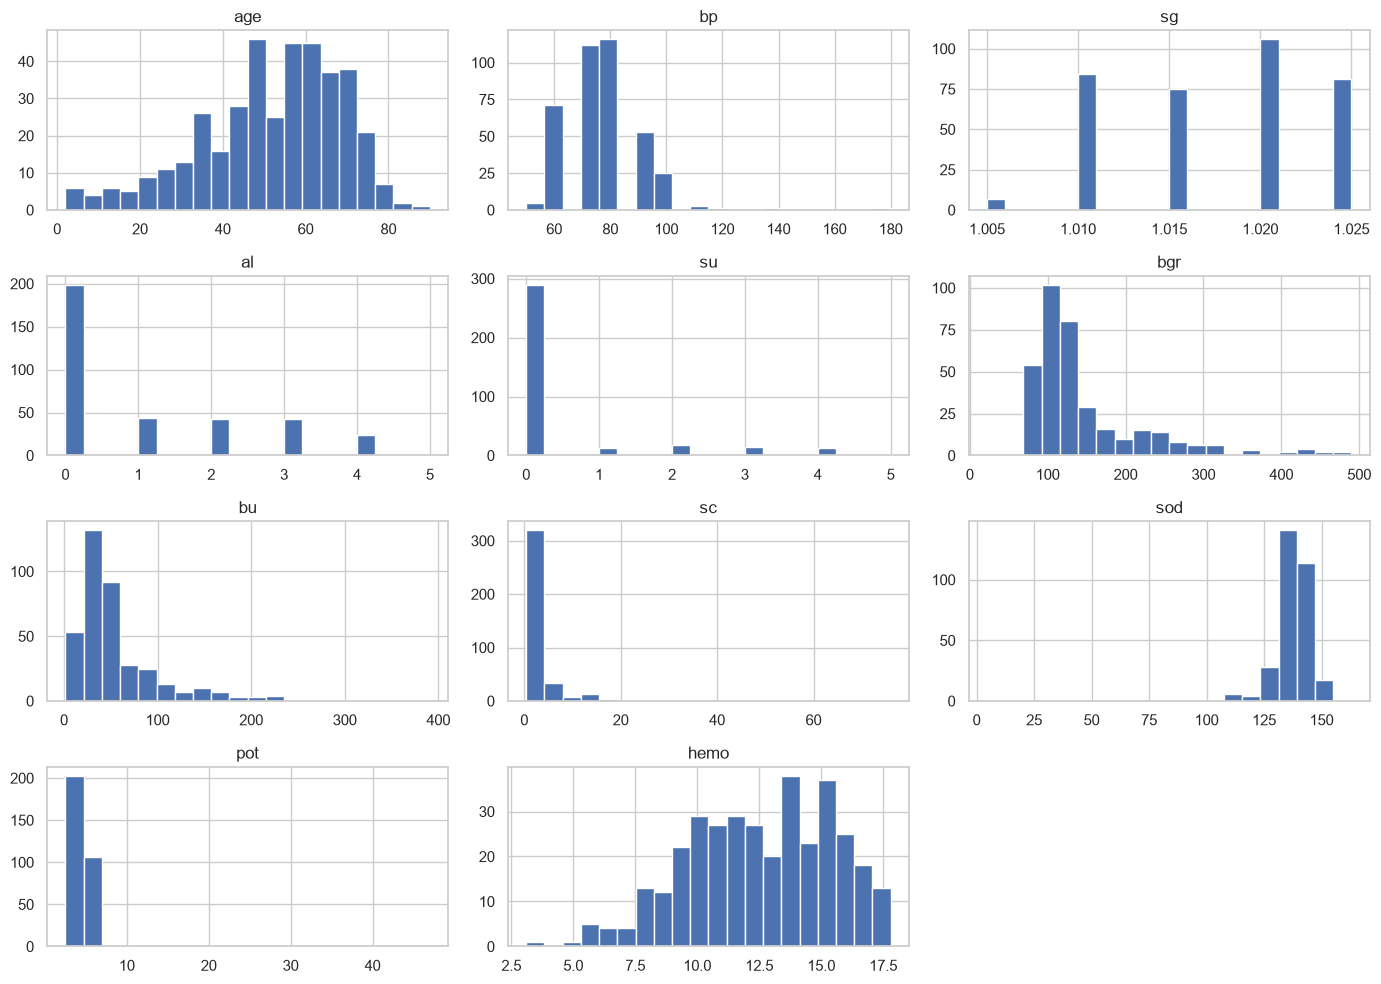

In [7]:
numeric_cols = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc",
                "sod", "pot", "hemo"]

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()


## 6. Categorical feature value counts
Check what values each categorical column actually has —
important for spotting inconsistent labels before encoding.

In [8]:
categorical_cols = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].astype(str).str.strip().value_counts())



rbc:
rbc
normal      201
abnormal     47
Name: count, dtype: int64

pc:
pc
normal      259
abnormal     76
Name: count, dtype: int64

pcc:
pcc
notpresent    354
present        42
Name: count, dtype: int64

ba:
ba
notpresent    374
present        22
Name: count, dtype: int64

htn:
htn
no     251
yes    147
Name: count, dtype: int64

dm:
dm
no     261
yes    137
Name: count, dtype: int64

cad:
cad
no     364
yes     34
Name: count, dtype: int64

appet:
appet
good    317
poor     82
Name: count, dtype: int64

pe:
pe
no     323
yes     76
Name: count, dtype: int64

ane:
ane
no     339
yes     60
Name: count, dtype: int64


## 7. Correlation heatmap (numeric columns only)

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap (numeric columns)")
plt.show()


## Notes / takeaways
_This dataset needs the most cleanup of all 5 — write down
which columns had messy values before moving to preprocessing._